# Data cleaing and transformation 

In [22]:
#importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
data = pd.read_csv("../data/amazon.csv")
print(f"datset: {data.shape[0]}rows, {data.shape[1]}columns ")

datset: 1465rows, 16columns 


In [3]:
data.dtypes

product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object

In [4]:
data.head(2)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...


The acutal discount price and actual price columns need to fix with symbol and convert into decimal 

In [5]:
#remove symbol and commas and convert into folat value 
data['discounted_price'] = data['discounted_price'].str.replace('₹', '', regex=False) #regex for replacing the extact text
data['discounted_price'] = data['discounted_price'].str.replace(',', '', regex=False)


#Removeing the symbol in acutal price column 
data['actual_price'] = data['actual_price'].str.replace('₹', '', regex=False)
data['actual_price'] = data['actual_price'].str.replace(',', '', regex=False)
data['actual_price'] = data['actual_price'].astype(float)



In [6]:
data['discounted_price'].dtype
data['actual_price'].dtype


dtype('float64')

In [7]:
# The discount percentage column strip % should be converted into integer
data['discount_percentage'] = data['discount_percentage'].str.replace('%', '', regex=False)
data['discount_percentage'] = data['discount_percentage'].astype(int)
data['discount_percentage'].dtype
print(data['discount_percentage'].head())

0    64
1    43
2    90
3    53
4    61
Name: discount_percentage, dtype: int64


In [8]:
# rating column have garbage values like "|" mixed in 

#covert to number 
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')

#checking how many bcome nan
data['rating'].isna().sum()

np.int64(1)

In [9]:
#drop the nan value row 
data = data.dropna(subset=['rating'])
print("rows after dropping bad raring :",len(data))

rows after dropping bad raring : 1464


--- proudct with rating of | tell sus noting 

In [10]:
#fixing the rating count column where values are comma sepreated 

#remove commas and convert to number
# data['rating_count'] = data['rating_count'].str.replace(',','',regex=False)
# data['rating_count'] = pd.to_numeric(data['rating_count'] ,errors='coerce')

data['rating_count'] = pd.to_numeric(data['rating_count'].astype(str).str.replace(',', '', regex=False),errors='coerce'
)

In [11]:
data['rating_count'].isna().sum()

np.int64(2)

---- There are 2 missing value in rating count ---

In [12]:
# fill the missing values with the median 

median_count = data['rating_count'].median()
data['rating_count'] = data['rating_count'].fillna(median_count)


- we use median over mean because the rating counts can be very skewe one viral prouct with 1million reivews would drawg the mean up unfailrly, thats why the median is more good 


In [13]:
# Extracting the main category as category look like 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables' 
# we will just keep the first part for goupin in eda

# Split on '|' and take the first item
data['main_category'] = data['category'].str.split('|').str[0]

print("Unique main categories:")
print(data['main_category'].value_counts())


Unique main categories:
main_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             447
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64


the full category path is tooo detailed for summary analysis so only main catergory lets us know which proudct category has been best reting or which have best discount 

### Discount Amount to know how much money a customer actulally saves 

In [14]:
data.dtypes

product_id              object
product_name            object
category                object
discounted_price        object
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count           float64
about_product           object
user_id                 object
user_name               object
review_id               object
review_title            object
review_content          object
img_link                object
product_link            object
main_category           object
dtype: object

In [15]:
data['discounted_price'].dtype

dtype('O')

In [16]:
data['discounted_price'] = data['discounted_price'].astype(float)

In [17]:
data['discounted_price'].dtype

dtype('float64')

In [18]:
# kati save garyo ta ekjana customer le per prodcts ?

data['discount_amount'] = data['actual_price'] - data['discounted_price']
print(data[["product_name","actual_price","discounted_price","discount_amount"]].head())

                                        product_name  actual_price  \
0  Wayona Nylon Braided USB to Lightning Fast Cha...        1099.0   
1  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...         349.0   
2  Sounce Fast Phone Charging Cable & Data Sync U...        1899.0   
3  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...         699.0   
4  Portronics Konnect L 1.2M Fast Charging 3A 8 P...         399.0   

   discounted_price  discount_amount  
0             399.0            700.0  
1             199.0            150.0  
2             199.0           1700.0  
3             329.0            370.0  
4             154.0            245.0  


# Final Check if data are all correct in proper data format 

In [19]:
# Final check on all columns
print(data[['discounted_price','actual_price','discount_percentage',
          'rating','rating_count','discount_amount']].dtypes)

print()
print("=== Missing Values After Cleaning ===")
print(data.isnull().sum())

print()
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

print()
print("=== Quick Stats on Clean Numeric Columns ===")
print(data[['discounted_price','actual_price','discount_percentage',
          'rating','rating_count','discount_amount']].describe().round(2))

discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count           float64
discount_amount        float64
dtype: object

=== Missing Values After Cleaning ===
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
main_category          0
discount_amount        0
dtype: int64

Rows: 1464, Columns: 18

=== Quick Stats on Clean Numeric Columns ===
       discounted_price  actual_price  discount_percentage   rating  \
count           1464.00       1464.00              1464.00  1464.00   
mean            3126.01       5447.00                47.71     4.10   
std           

Since all data are in their original datatype and with no any null column in every column . so we save our cleaned data to aq new file so we never touch the raw data again 

# Outlier Detection

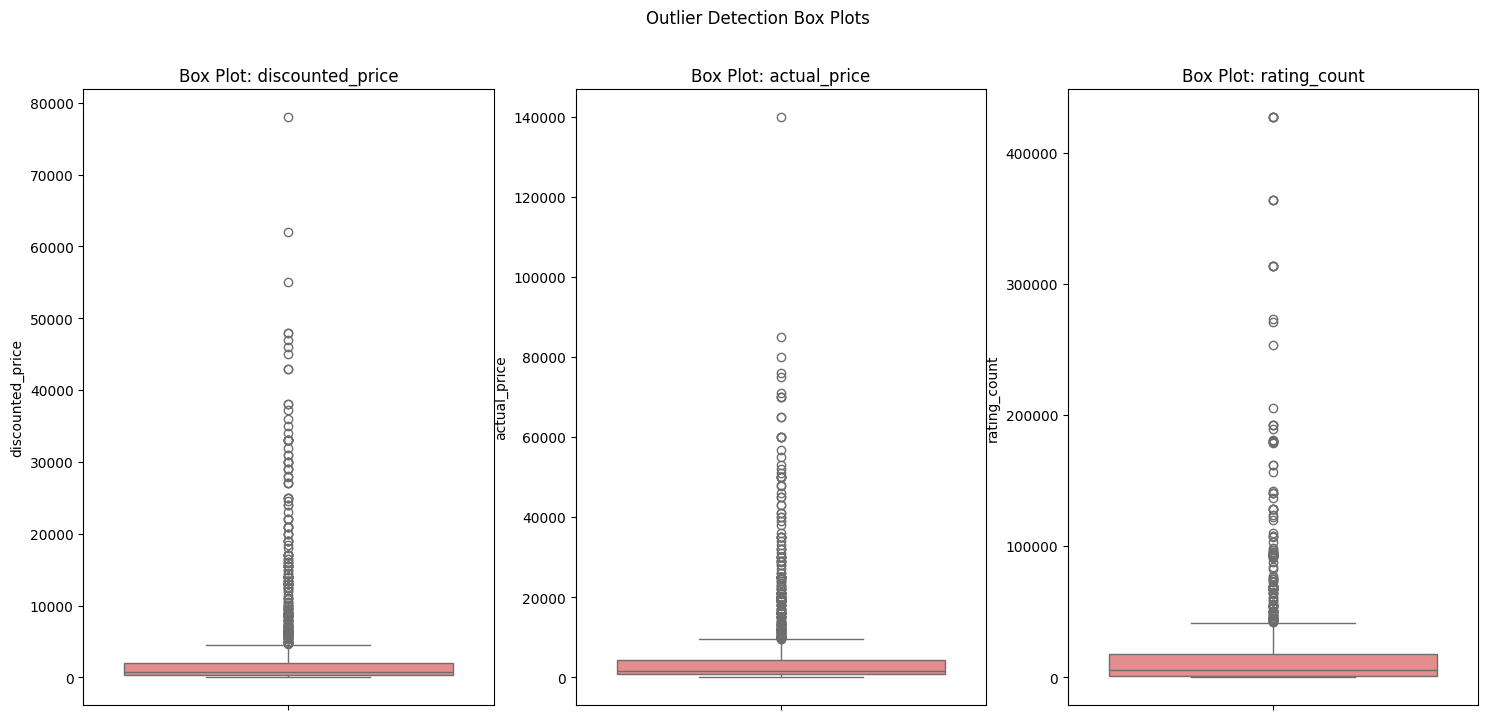

In [27]:
#(data point that is unsually fat from rest of other data)

#checking 3 key numeric columns for outlier

cols_to_check = ['discounted_price','acutal_price','rating_count']
fig, axes = plt.subplots(1,3 ,figsize=(18,8))
# First plot
sns.boxplot(y=data['discounted_price'], ax=axes[0], color='lightcoral')
axes[0].set_title('Box Plot: discounted_price')
axes[0].set_ylabel('discounted_price')

# Second plot
sns.boxplot(y=data['actual_price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Box Plot: actual_price')
axes[1].set_ylabel('actual_price')

# Third plot
sns.boxplot(y=data['rating_count'], ax=axes[2], color='lightcoral')
axes[2].set_title('Box Plot: rating_count')
axes[2].set_ylabel('rating_count')

plt.suptitle('Outlier Detection Box Plots')
plt.savefig("../Figures/outlier detection")
plt.show()

the dots floating above the box are all outliers . the more above the dots they are the expensive things 


In [25]:
#Calculating the IQR
for col in ['discounted_price', 'actual_price', 'rating_count']:
     q1 = data[col].quantile(0.25)
     q3 = data[col].quantile(0.75)
     iqr = q3 - q1
#Calculating the IQR
     lower = q1 - 1.5 * iqr
     upper = q3 + 1.5 * iqr
#count the outlier
     outliers = data[(data[col] < lower) | (data[col] > upper)]

     print("\nColumn:", col)
     print("Q1:", q1)
     print("Q3:", q3)
     print("IQR:", iqr)
     print("Number of outliers:", len(outliers))


Column: discounted_price
Q1: 323.75
Q3: 1999.0
IQR: 1675.25
Number of outliers: 217

Column: actual_price
Q1: 800.0
Q3: 4303.75
IQR: 3503.75
Number of outliers: 213

Column: rating_count
Q1: 1192.5
Q3: 17330.75
IQR: 16138.25
Number of outliers: 141


#### Discounted Price
#### In the discounted price the discounted prices lie btween 323 to 1999 where IOQ is 1675 is very large with outlieris 217. 
##### Meaning:
- There are:
- Very cheap products (possibly errors or low-value items)
- Very expensive discounted products (premium items)


#### Acutal Price
#### In the actual price IQR is 3505 which is huge variation in prouct prices with outlieris 213 with extreme values. 
##### Meaning:
-- There are:
- Very cheap products (possibly errors or low-value items)
- Very expensive products (premium items)

--Insight:
- This is a mixed market dataset (low + high price items)
- Strong right skew likely (few very expensive items)


#### rating count
#### In the rating count IQR is 16138 which is huge variation in popularity with outlieris 141 with fewer than price coluns but still significant . 
##### Meaning:
-- There are:
- SOme proucts have extremely high ratings 
- Many have moderate engagement

--Insight:
- This is highly skewed poupularity distribution

In [29]:
# Outlier Treatment capping because if we delete the outlier we lose real data in real proudct where in cappin gwe repladce extreme values with the bounday values
# Create a copy to store capped values
data_capped = data.copy()

cols_to_cap = ['discounted_price', 'actual_price', 'rating_count']

for col in cols_to_cap:
    Q1 = data_capped[col].quantile(0.25)
    Q3 = data_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Cap: anything below lower becomes lower, above upper becomes upper
    data_capped[col] = data_capped[col].clip(lower=lower, upper=upper)

    print(f"{col}:")
    print(f"Before → max: {data[col].max():,.0f}")
    print(f"After  → max: {data_capped[col].max():,.0f}")
    print()

discounted_price:
Before → max: 77,990
After  → max: 4,512

actual_price:
Before → max: 139,900
After  → max: 9,559

rating_count:
Before → max: 426,973
After  → max: 41,538



.clip() is the simplest way to cap one line per coulumn 

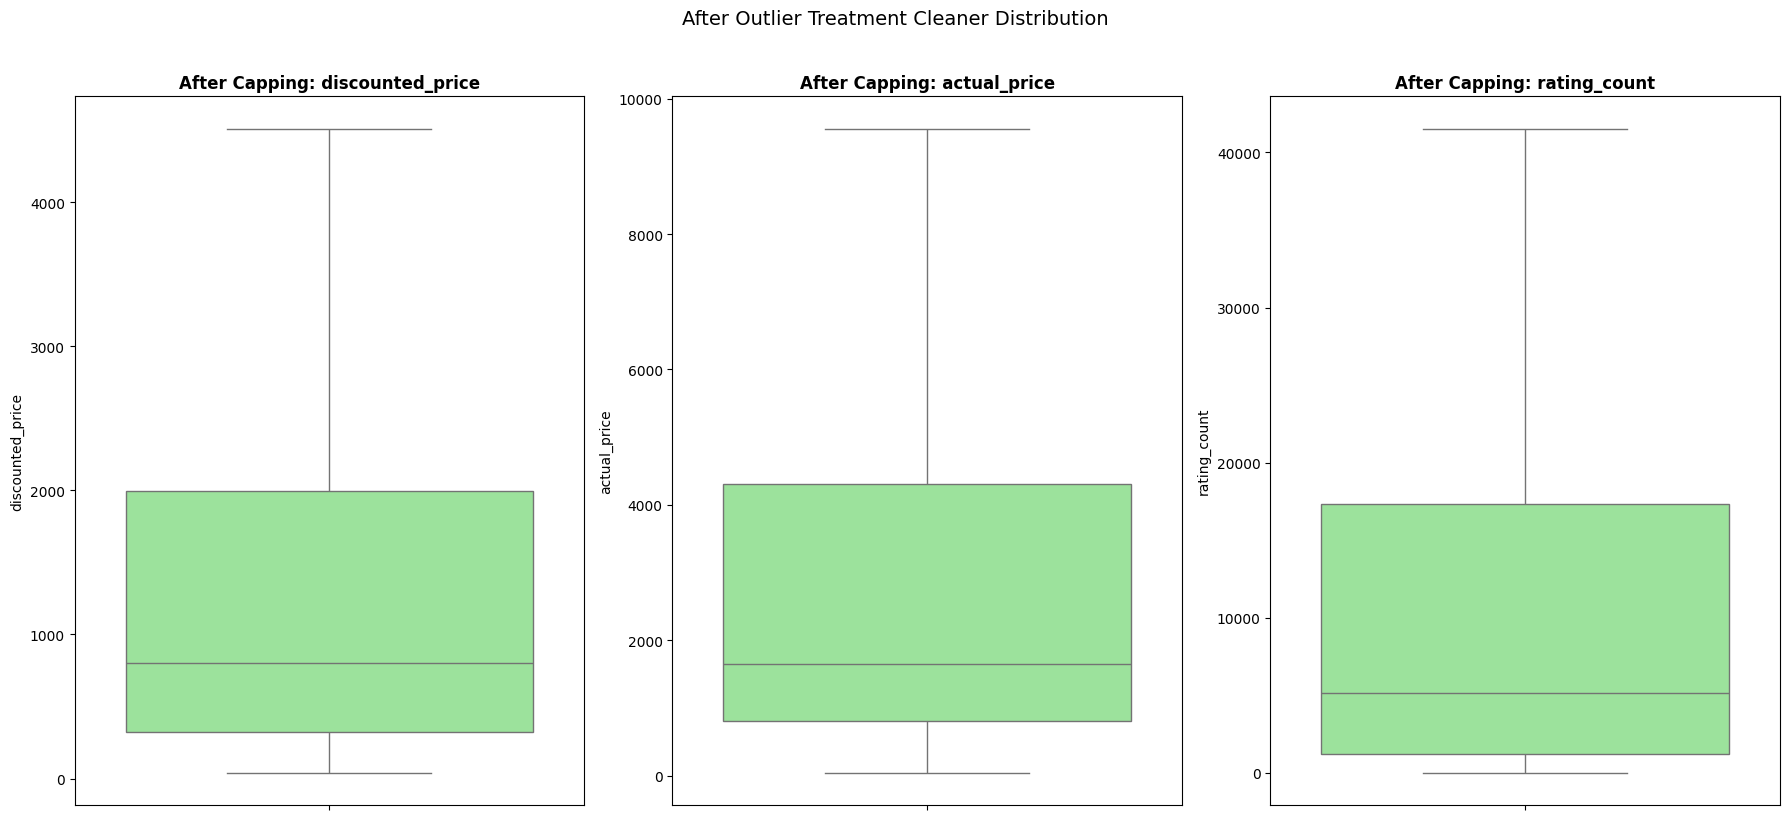

In [31]:
#BOx plot after capping 
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, col in zip(axes, cols_to_cap):
    sns.boxplot(y=data_capped[col], ax=ax, color='lightgreen')
    ax.set_title(f'After Capping: {col}', fontweight='bold')

plt.suptitle('After Outlier Treatment Cleaner Distribution', fontsize=14, y=1.02)
plt.savefig("../data/After outlier treatment")
plt.tight_layout()
plt.show()


In [20]:
# Export to clean CSV
data.to_csv('../data/amazon_cleaned.csv', index=False)

# Cleaned SUmmary

- fixed prices and removed  ₹ and commas to converted into float 
- Fix discounts and  Removed % and converted to int 
- Fix ratings Forced to numeric, dropped 1 bad row 
- Fix rating count Removed commas and  filled 2 NaNs with median 
- Extract category Created `main_category` 
- New feature Created `discount_amount`
